# Gazepoint

## Setup

In [1]:
import sys
import os
from IPython.display import Image
import pandas as pd

# Replace with the actual path to your pyxations package
package_path = "../pyxations"
sys.path.append(package_path)

In [2]:
import pyxations as pyx

## Dataset to BIDS

The filenames in the dataset folder are assumed to have the following structure for Gazepoint data.

In [3]:
current_folder = os.getcwd()
current_folder = os.path.join(os.path.dirname(current_folder),"tests","data")
files_folder_path = os.path.join(current_folder,"gazepoint_files")
bids_dataset_folder = pyx.dataset_to_bids(current_folder,files_folder_path,"gazepoint_dataset", format_name='gaze')

In [4]:
print(bids_dataset_folder)

D:\OneDrive - UBA\pyxations\tests\data\gazepoint_dataset


## Compute derivatives

In [5]:
dataset_type = 'gaze'
detection_algorithm = 'remodnav'
pyx.compute_derivatives_for_dataset(bids_dataset_folder, dataset_type, detection_algorithm, 
                                    overwrite=True)

WindowsPath('D:/OneDrive - UBA/pyxations/tests/data/gazepoint_dataset_derivatives')

## Load data and plots

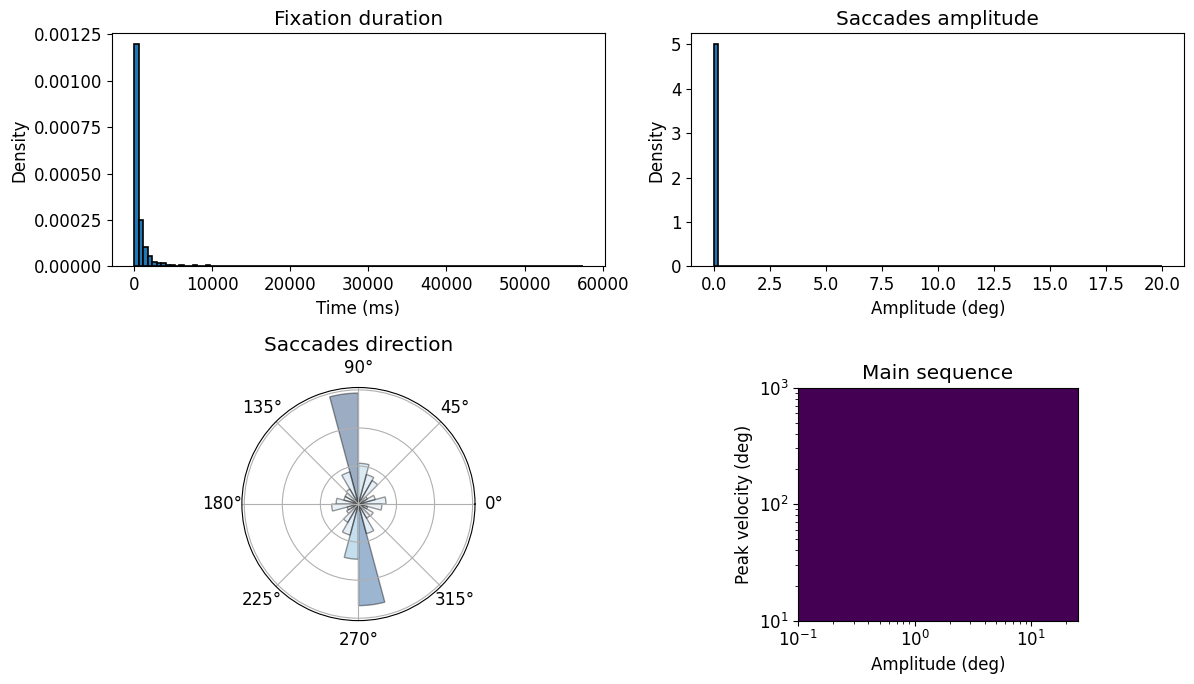

In [6]:
exp = pyx.Experiment(bids_dataset_folder)
exp.load_data("remodnav")

# Some plots
exp.plot_multipanel(True)

In [7]:
exp.subjects

{'0001': Subject = '0001', Experiment = 'gazepoint_dataset'}

In [8]:
exp.subjects['0001'].sessions

{'A': Session = 'A', Subject = '0001', Experiment = 'gazepoint_dataset'}

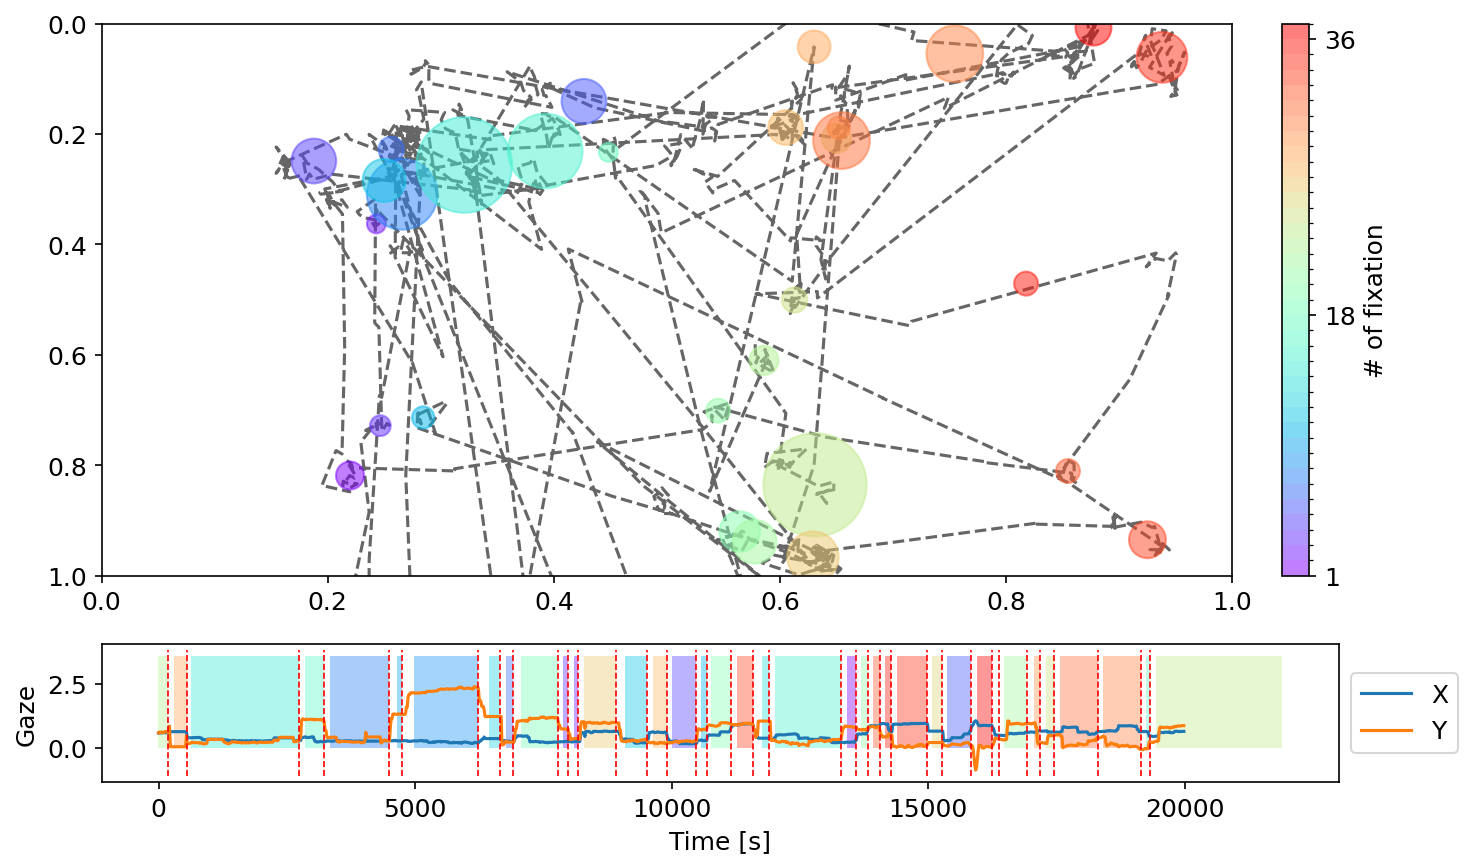

In [9]:
# The whole recording is treated as a single "complete_recording" trial.
# plot_scanpath assigns one colour per fixation and caps at 256, so we plot a
# time window (first 20 s) instead of all fixations. Gazepoint gaze is normalized
# 0-1, so we pass a unit screen (height=1, width=1).
trial = exp.subjects['0001'].get_trial(session_id='A', trial_number=0)
fix = trial.fixations()
t0 = fix['tStart'].min()
trial.plot_scanpath(1, 1, tmin=t0, tmax=t0 + 20000)

In [10]:
# Retrieve data for the trial
exp.get_trial(subject_id='0001', session_id='A', trial_number=0).fixations()

tStart,tEnd,xStart,yStart,xEnd,yEnd,ampDeg,vPeak,med_vel,avg_vel,duration,xAvg,yAvg,pupilAvg,Eyes_recorded,Rate_recorded,eye,bad,phase,trial_number,trial_label
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,null,f64,str,bool,str,i64,str
1.6705e6,1.6707e6,-0.654997,-3.692667,0.134906,-3.051371,0.018623,0.954682,0.383029,0.368867,197.903309,0.432543,-2.592729,0.0,null,60.635671,"""Best""",true,"""complete_recording""",0,""""""
2.2142e6,2.2143e6,-0.413425,1.536545,-0.392424,1.52521,0.000437,0.016459,0.00403,0.005636,115.443597,-0.396383,1.528465,0.0,null,60.635671,"""Best""",true,"""complete_recording""",0,""""""
111221.659869,111370.087351,-0.343388,1.351143,-0.328821,1.342073,0.000314,0.103396,0.0,0.027769,148.427482,-0.27264,1.30053,0.0,null,60.635671,"""Best""",true,"""complete_recording""",0,""""""
222690.698875,222822.634414,-0.173657,0.461232,-0.201208,0.463899,0.000507,0.034726,0.008869,0.011593,131.93554,-0.15551,0.47248,0.0,null,60.635671,"""Best""",true,"""complete_recording""",0,""""""
87819.593535,87968.021017,-0.124773,0.047261,-0.065838,0.035774,0.001099,0.050616,0.016188,0.016968,148.427482,-0.12326,0.01326,0.0,null,60.635671,"""Best""",true,"""complete_recording""",0,""""""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1.5249e6,1.5250e6,1.29302,0.064403,1.294633,0.076315,0.00022,0.057185,0.018839,0.025232,98.951655,1.210292,0.151344,0.0,null,60.635671,"""Best""",true,"""complete_recording""",0,""""""
1.1338e6,1.1342e6,1.294005,-0.213574,0.945613,-0.805573,0.012573,0.222274,0.050984,0.078266,412.298561,0.999342,-0.28412,0.0,null,60.635671,"""Best""",true,"""complete_recording""",0,""""""
1.9826e6,1.9829e6,1.30871,0.045105,1.173707,-0.00634,0.002644,0.040903,0.006489,0.014039,263.871079,1.254532,0.051005,0.0,null,60.635671,"""Best""",true,"""complete_recording""",0,""""""


## Animation

In [ ]:
# Animate straight from the `trial` we already loaded above
trial.plot_animation(
    screen_height=1080, screen_width=1920,
    seconds_to_show=5, fps=30,
    output_format='html', display=True,
    in_percent=True,
)